In [1]:
import numpy as np
import pandas as pd
import seaborn as sns 
import matplotlib.pyplot as plt 

from sklearn.linear_model import LogisticRegression


from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

import sys 
sys.path.insert(0, r"C:\Users\jcmar\my_files\SportsBetting\ModelStrategy")


In [2]:
from FeatureSelection.lasso import plot_lasso_path, rank_features_by_lasso_path
from LogisticRegression.get_train_test import TrainTestBuilder  
from feats_config import FeatsConfig


In [9]:
fp = r'C:\Users\jcmar\my_files\SportsBetting\data\training_data\entire_odds_stats_2026-03-09.csv'
df_model = pd.read_csv(fp)

df_model['math_red'] = df_model['math_red'].astype('category')
df_model['math_blue'] = df_model['math_blue'].astype('category')
df_model['elo_pred'] = df_model['elo_pred'].astype('category')


non_feats = FeatsConfig.non_feats_open
selected_feats = FeatsConfig.selected_feats_open


y = 'winner'
builder = TrainTestBuilder(df=df_model, target_col=y, non_features=non_feats, train_size=0.85, random_state=42)
builder.filter_by_date(year=2010, month=2, day=26, date_col='event_date')

X_train, X_test, y_train, y_test, df_train, df_test, scaler_open = builder.prepare_train_test(selected_feats, outlier_dict=None)



Filtered: kept 6650 rows from 2010-02-26 onward.
PREPARE SHAPE: (4256, 297)
MODEL SHAPE: (4177, 297)
Categorical columns: ['elo_pred']
Numerical columns: ['proba_fair_open_diff', 'reach_diff', 'sub_att_pm_red', 'sub_att_pm_blue', 'ratio_control_diff', 'td_landed_pm_diff', 'ratio_td_diff', 'adjusted_td_red', 'adjusted_td_blue', 'sig_str_absorbed_total_diff', 'sig_str_accuracy_pct_diff', 'sig_str_defense_pct_diff', 'adjusted_sig_str_blue', 'adjusted_sig_str_red', 'win_pct_red', 'win_pct_blue', 'win_streak_diff', 'lose_streak_diff', 'elo_red', 'elo_blue', 'age_red', 'age_blue']


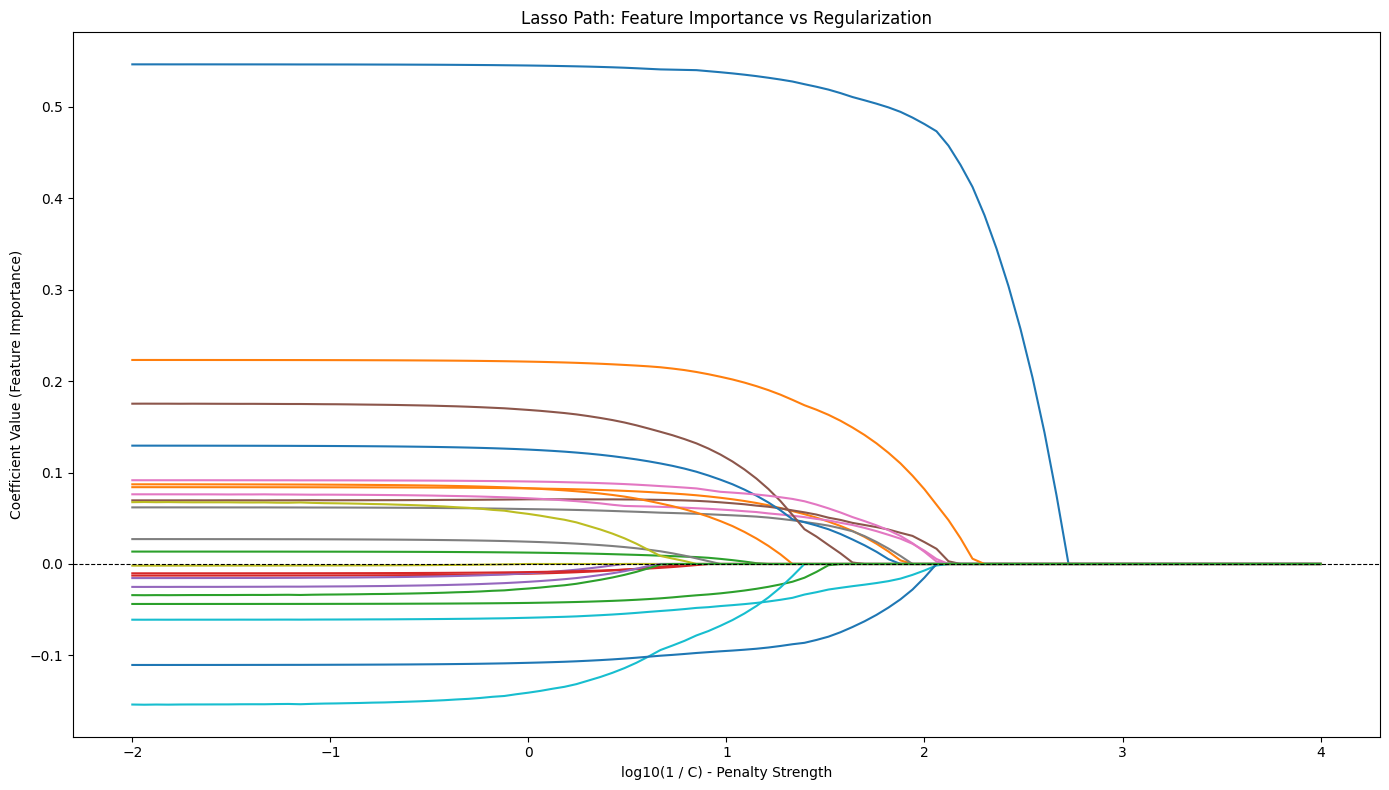

                             vanish_index  rank
proba_fair_open_diff                   78     1
age_blue                               71     2
td_landed_pm_diff                      69     3
ratio_td_diff                          68     4
win_streak_diff                        68     4
sig_str_absorbed_total_diff            68     4
age_red                                67     7
adjusted_td_red                        65     8
reach_diff                             65     8
sig_str_accuracy_pct_diff              64    10
win_pct_blue                           61    11
adjusted_sig_str_blue                  59    12
elo_blue                               56    13
sig_str_defense_pct_diff               56    13
sub_att_pm_red                         53    15
adjusted_sig_str_red                   49    16
lose_streak_diff                       49    16
elo_red                                48    18
sub_att_pm_blue                        47    19
elo_pred                               4

In [10]:
C_min=1e-4
C_max=1e2
num_C=100
C_values = np.logspace(np.log10(C_max), np.log10(C_min), num_C)

coef_df = plot_lasso_path(X_train, y_train, C_min=1e-4, C_max=1e2, num_C=num_C, figsize=(14,8))
rank_df = rank_features_by_lasso_path(coef_df, C_values)


In [14]:
df_model['math_red'] = df_model['math_red'].astype('category')
df_model['math_blue'] = df_model['math_blue'].astype('category')


bad_cols = ['proba_fair_open_red', 'proba_fair_open_blue', 'pimp_open_red', 'pimp_open_blue', 'dec_fair_open_red', 'dec_fair_open_blue',
            'dec_open_red', 'dec_open_blue', 'open_red', 'open_blue', 'juice_open_red', 'juice_open_blue', 'elo_red_proba', 'elo_blue_proba',
            'dog_counts_red', 'dog_counts_blue', 'fav_counts_red', 'fav_counts_blue']

non_diff_feats = [feat for feat in df_model.columns if feat.endswith('_diff') is False]
non_diff_feats = [x for x in non_diff_feats if x not in bad_cols]

y = 'winner'

builder = TrainTestBuilder(df=df_model, target_col=y, non_features=FeatsConfig.non_feats_open, train_size=0.85, random_state=42)
builder.filter_by_date(year=2010, month=2, day=26, date_col='event_date')
X_train, X_test, y_train, y_test, df_train, df_test, scaler_open = builder.prepare_train_test(non_diff_feats, outlier_dict=None, one_hot_encode=True)

Filtered: kept 6650 rows from 2010-02-26 onward.
PREPARE SHAPE: (4256, 297)
MODEL SHAPE: (4177, 297)
Categorical columns: ['weight_class', 'elo_pred', 'math_red', 'math_blue', 'womens_fight']
Numerical columns: ['td_defense_pct_red', 'td_total_attempted_against_red', 'td_total_landed_against_red', 'td_defense_pct_blue', 'td_total_attempted_against_blue', 'td_total_landed_against_blue', 'sig_str_defense_pct_red', 'sig_str_total_attempted_against_red', 'sig_str_total_landed_against_red', 'sig_str_defense_pct_blue', 'sig_str_total_attempted_against_blue', 'sig_str_total_landed_against_blue', 'td_accuracy_pct_red', 'td_accuracy_pct_blue', 'sig_str_accuracy_pct_red', 'sig_str_accuracy_pct_blue', 'kd_pm_red', 'kd_total_red', 'kd_pm_blue', 'kd_total_blue', 'sig_str_landed_pm_red', 'sig_str_landed_total_red', 'sig_str_landed_pm_blue', 'sig_str_landed_total_blue', 'sig_str_absorbed_pm_red', 'sig_str_absorbed_total_red', 'sig_str_absorbed_pm_blue', 'sig_str_absorbed_total_blue', 'sig_str_attempt

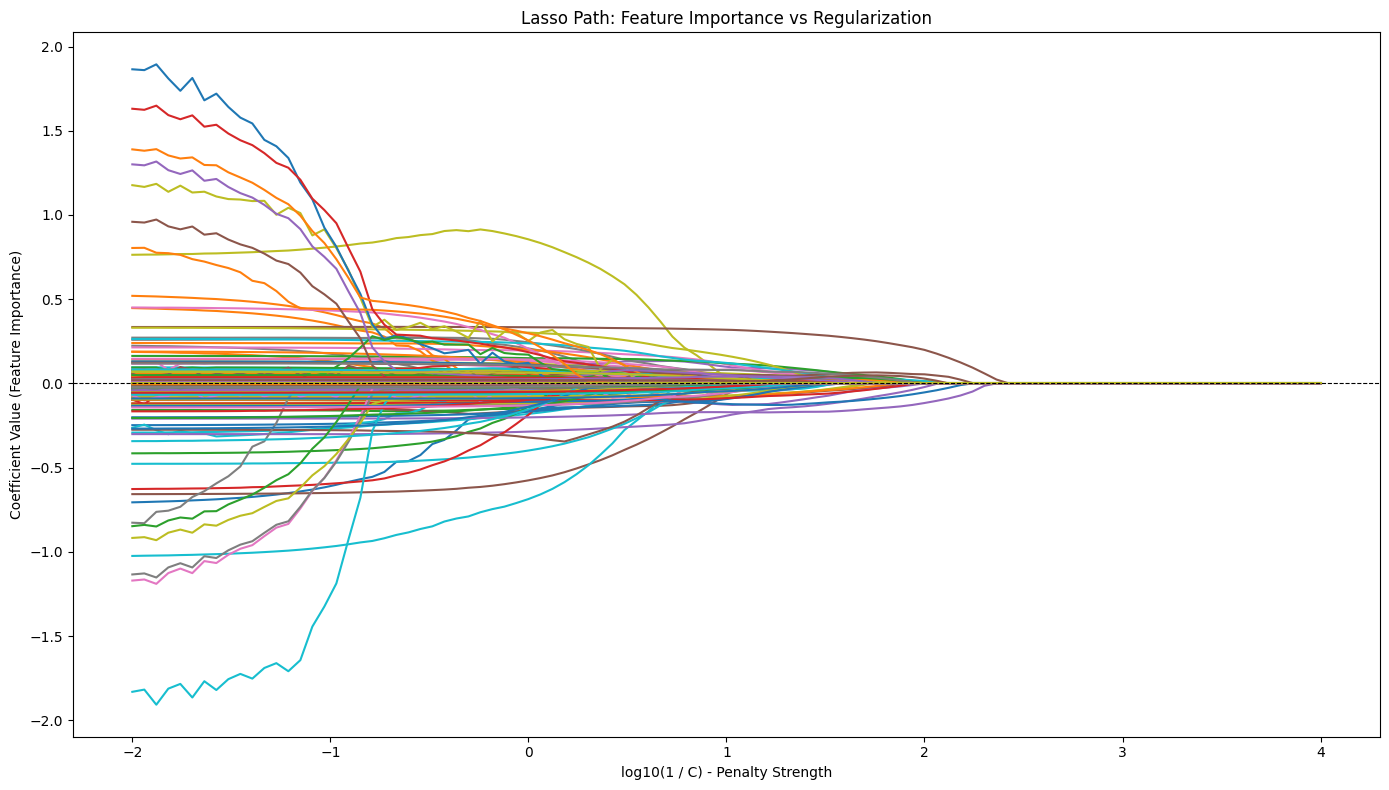

                                      vanish_index  rank
age_blue                                        73     1
age_red                                         72     2
win_pct_red                                     71     3
ko_losses_red                                   70     4
elo_pred_1                                      69     5
td_attempted_pm_blue                            68     6
adjusted_td_red                                 68     6
td_landed_pm_red                                68     6
ratio_td_red                                    67     9
win_streak_red                                  67     9
win_streak_blue                                 66    11
ratio_control_red                               66    11
num_losses_blue                                 66    11
sub_pct_red                                     66    11
sig_str_absorbed_pm_red                         66    11
td_attempted_pm_red                             66    11
ratio_td_blue                  

In [17]:

coef_df = plot_lasso_path(X_train, y_train, C_min=1e-4, C_max=1e2, num_C=num_C, figsize=(14,8))
rank_df = rank_features_by_lasso_path(coef_df, C_values)


In [18]:
diff_feats = [feat for feat in df_model.columns if feat.endswith('_diff')]

y = 'winner'
builder = TrainTestBuilder(df=df_model, target_col=y, non_features=non_feats, train_size=0.85, random_state=42)
builder.filter_by_date(year=2010, month=2, day=26, date_col='event_date')
X_train, X_test, y_train, y_test, df_train, df_test, scaler_open = builder.prepare_train_test(diff_feats, outlier_dict=None)


Filtered: kept 6650 rows from 2010-02-26 onward.
PREPARE SHAPE: (4256, 297)
MODEL SHAPE: (4177, 297)
Categorical columns: []
Numerical columns: ['ratio_td_diff', 'ratio_control_diff', 'ratio_sigstrike_diff', 'kd_total_diff', 'kd_pm_diff', 'sig_str_landed_total_diff', 'sig_str_landed_pm_diff', 'sig_str_absorbed_total_diff', 'sig_str_absorbed_pm_diff', 'sig_str_attempted_total_diff', 'sig_str_attempted_pm_diff', 'leg_str_total_diff', 'leg_str_pm_diff', 'head_str_total_diff', 'head_str_pm_diff', 'body_str_total_diff', 'body_str_pm_diff', 'clinch_str_total_diff', 'clinch_str_pm_diff', 'td_landed_total_diff', 'td_landed_pm_diff', 'td_attempted_total_diff', 'td_attempted_pm_diff', 'control_total_diff', 'control_pm_diff', 'sub_att_total_diff', 'sub_att_pm_diff', 'reverse_total_diff', 'reverse_pm_diff', 'age_diff', 'height_diff', 'reach_diff', 'sig_str_defense_pct_diff', 'sig_str_accuracy_pct_diff', 'td_accuracy_pct_diff', 'td_defense_pct_diff', 'avg_fight_min_diff', 'total_bonus_diff', 'elo_d

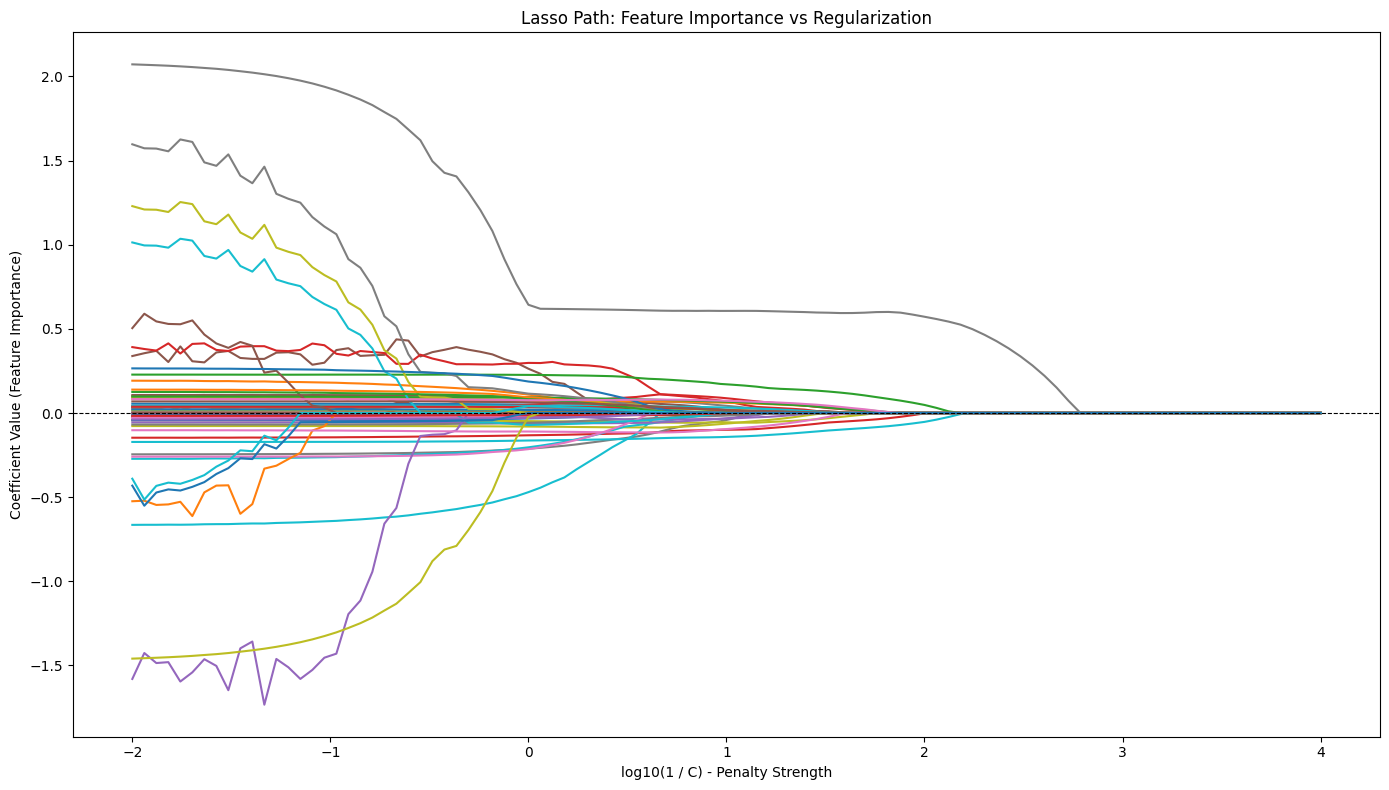

                              vanish_index  rank
proba_fair_close1_diff                  79     1
age_diff                                70     2
td_attempted_pm_diff                    69     3
kd_total_diff                           67     4
win_streak_diff                         64     5
proba_fair_open_diff                    64     5
reach_diff                              63     7
sig_str_absorbed_pm_diff                63     7
sig_str_accuracy_pct_diff               63     7
sub_att_total_diff                      60    10
win_pct_diff                            60    10
glicko_diff                             59    12
head_str_total_diff                     59    12
sub_pct_diff                            58    14
clinch_str_pm_diff                      58    14
clinch_str_total_diff                   57    16
td_accuracy_pct_diff                    57    16
elo_diff                                56    18
reverse_total_diff                      54    19
control_pm_diff     

In [19]:

coef_df = plot_lasso_path(X_train, y_train, C_min=1e-4, C_max=1e2, num_C=num_C, figsize=(14,8))
rank_df = rank_features_by_lasso_path(coef_df, C_values)
print(rank_df)
